## Computing multivariate probabilities from univariate probabilities
### By Jorge I. Zuluaga

### The problem

We have a set of physical variables $\mathbf{x}:\{x_1, x_2, ..., x_N\}$ that determines the value of an observable $r = f(\mathbf{x})$.  

With an experiment or a theory we determine how the values of $r$ are statistically distributed, i.e. we know the probability distribution function (pdf) $p(r)$, such that the probability that $r\in(r-dr,r+dr)$ is $p(r)dr$.

The goal is to determine the joint pdf of the original variables, i.e. find $q(\mathbf{x})$, such that the probability of $\mathbf{x}$ be in a ball of radius $d\mathbf{x}$ is $p(\mathbf{x})d^N\mathbf{x}$, with $d^N\mathbf{x}$ the hipervolume differential.

### An illustration example

The density of a star is given by: 

$$
\rho = \frac{kM}{R^3}
$$
where $1/k=4\pi/3$

We measure the density using an observational method, which give us the distribution $p(\rho)$ (for instance a normal distribution with mean $\bar\rho$ and standard deviation $\Delta\rho$). Our goal is to determine how $M$ and $R$ are distributed, i.e. to find the pdf $q(M,R)$. In this case the function $f(M,R)$ is:

$$
f(M,R) = \frac{kM}{R^3}
$$

### Intuitive approach

An intuitive numerical approach to the solution of the problem is to randomly generate test values of $\mathbf x_k$ and then use the probability $p(f(\mathbf x_k))$ to accept or reject them in order to obtain a set of sample values $\mathbf{x}_i$. We can do this in two ways:

> **NOTE**: Hereafter we will use the index $k$ to indicate a test value, $i$ is the index of a sample value and $j$ is the index for a given variable.

1. **Monte Carlo Rejection Algorithm** (MCRA). For that purpose we generate a large set of test of values $\mathbf{x}_k \sim$ Uniform $\left(\left[a_1, b_1\right] \times \cdots \times\left[a_N, b_N\right]\right)$, where $[a_j,b_j]$ is the interval for variable $x_j$.  For each test value we computhe the corresponding value of $r$, ie. $r_k = f(\mathbf{x}_k)$

    The values are accepted with acceptance probability:

    $$
    p_{\mathrm acc} = p(r_k)
    $$

    Acceptance probability means that in order to accept the test vector $\mathbf{x}_k$ we first generate a value $u\in[0,\mathrm{max}(p(r))]$ and accept the test vector if $u<p_{\mathrm acc}$.

    *Pros*: This method is straight-forward and easy to program. It can explore thoroughly a region.
    
    *Cons*: It may require a lot of points to sample the parameter space.


2. **Markov Chain Monte Carlo** (MCMC). For this purpose we start with initial guessing value $\mathbf{x}_0$. A new test value is generated using, either a gaussian distribution centered around the previous value $\mathbf{x}_{k+1} \sim \mathcal{N}(\mathbf{x}_k, \Sigma)$, with $\Sigma$ a covariance matrix, or using a random walk namely $\mathbf{x}_{k+1} = \mathbf{x}_{k} + \delta\mathbf{x}$, where $\delta\mathbf{x} \sim \mathcal{N}(0, \Sigma)$.  Both methods works similarly. The acceptance probability is:

    $$
    p_{\mathrm acc} = \mathrm{min}\left\{1,\frac{p(f(\mathbf{x}_{k+1}))}{p(f(\mathbf{x}_{k}))}\right\}
    $$
    
    A covariance matrix is defined as:

    $$
    \Sigma = \begin{pmatrix}
    \sigma_1^2 & \rho_{12} \sigma_1 \sigma_2 & \rho_{13} \sigma_1 \sigma_3 & \cdots & \rho_{1N} \sigma_1 \sigma_N \\
    \rho_{21} \sigma_2 \sigma_1 & \sigma_2^2 & \rho_{23} \sigma_2 \sigma_3 & \cdots & \rho_{2N} \sigma_2 \sigma_N \\
    \rho_{31} \sigma_3 \sigma_1 & \rho_{32} \sigma_3 \sigma_2 & \sigma_3^2 & \cdots & \rho_{3N} \sigma_3 \sigma_N \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    \rho_{N1} \sigma_N \sigma_1 & \rho_{N2} \sigma_N \sigma_2 & \rho_{N3} \sigma_N \sigma_3 & \cdots & \sigma_N^2
    \end{pmatrix}
    $$

    where $\sigma_j$ are the standard error for variable $j$ and $\rho_{jl}$ is the correlation among variables $j$th and $k$th. As you may guess in most cases we probably do not know what is the value of those $\rho$. As a rule of thumb you may set $\rho_{jl}=0$ and $\sigma_j$ similar to the grid size in the case of MCRA. 

    *Pros*: It works for exploring the parameter space when no bounds are defined.
    
    *Cons*: The method is harder to implement. Covariance matrix is unknown and should be properly selected. The method could abandon easily regions of large probabilities.

### Example implementation

Let's implement this approach for the case of the density, mass and radius. Let's assume that we know that in a given units the density of a star is normally distributed with $\bar\rho=1$ and $\Delta\rho=0.1$. We want to find a sample of values of $R$ and $M$ and from it get an estimate of the distribution $q(M,R)$.

First we define the routines:

In [1]:
#+COPILOT
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the normal distribution of rho
rho_mean = 1.0
rho_std = 0.1
k=3/(4*np.pi)

# Function to calculate rho given M and R
def calculate_rho(M, R):
    return k * M / R**3

# Probability density function for rho
def p_rho(rho):
    return (1/(rho_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((rho - rho_mean) / rho_std)**2)

#### Implementation MCMC

For the MCMC we will use a gaussian random walk with size $\delta\mathbf{x}:(0.1,0.1)$ and an initial value $(M,R)=(1,1)$ (which satisfy $\rho=kM/R^3=\bar{rho}$).

In [2]:
#+COPILOT
# MCMC parameters
num_samples = int(1e6)
M_init, R_init = 1.0, 1.0
samples = []

# MCMC sampling
M, R = M_init, R_init
for _ in range(num_samples):
    # Random walk
    M_new = M + np.random.normal(0, 0.1)
    R_new = R + np.random.normal(0, 0.1)
    
    rho = calculate_rho(M, R)
    rho_new = calculate_rho(M_new, R_new)
    
    acceptance_ratio = p_rho(rho_new) / p_rho(rho)
    
    if acceptance_ratio > np.random.rand():
        M, R = M_new, R_new
    
    samples.append((M, R))

samples = np.array(samples)
rhos = calculate_rho(samples[:,0],samples[:,1])

One characteristic of the MCMC is that many points are repeated:

In [3]:
len(samples), len(np.unique(samples[:,1]))

(1000000, 546672)

Still they provide enough evidence to reconstruct the probability distribution.

Let's plot the result:

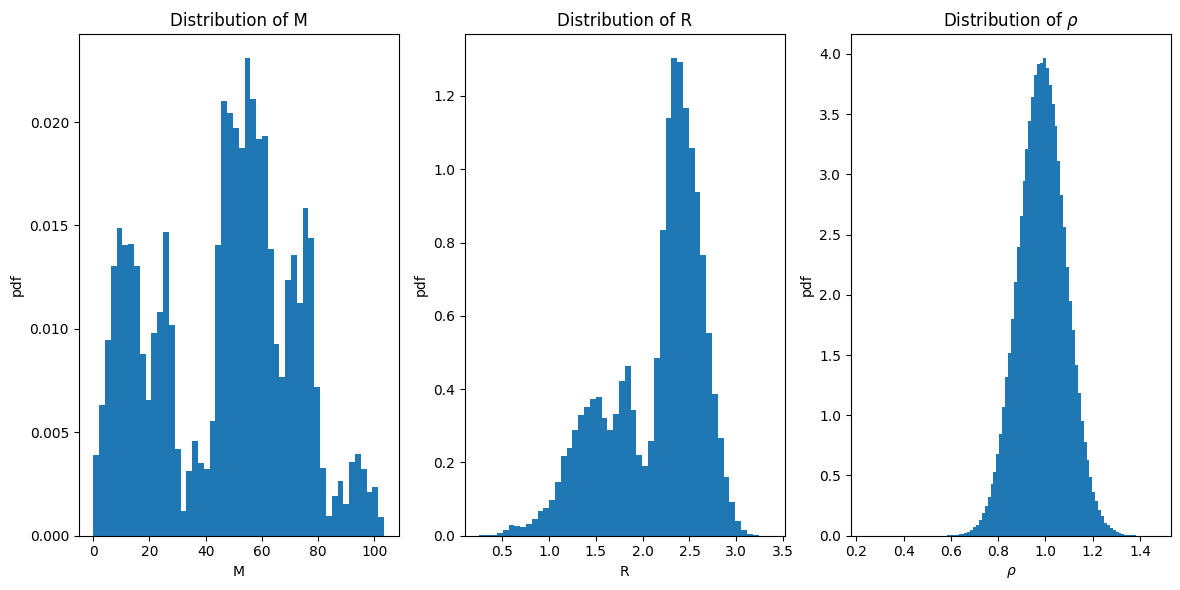

In [19]:
#+COPILOT+Mods
# Plotting the results
fig, axs = plt.subplots(1,3,figsize=(12, 6))
ax = axs[0]
ax.hist(samples[:, 0], bins=50, density=True)
ax.set_xlabel('M')
ax.set_ylabel('pdf')
ax.set_title('Distribution of M')

ax = axs[1]
ax.hist(samples[:, 1], bins=50, density=True)
ax.set_xlabel('R')
ax.set_ylabel('pdf')
ax.set_title('Distribution of R')

ax = axs[2]
ax.hist(rhos,bins=100,density=True)
ax.set_xlabel(r'$\rho$')
ax.set_ylabel('pdf')
ax.set_title(r'Distribution of $\rho$')

fig.tight_layout()



We may also use a scatter plot and a 2d histogram:

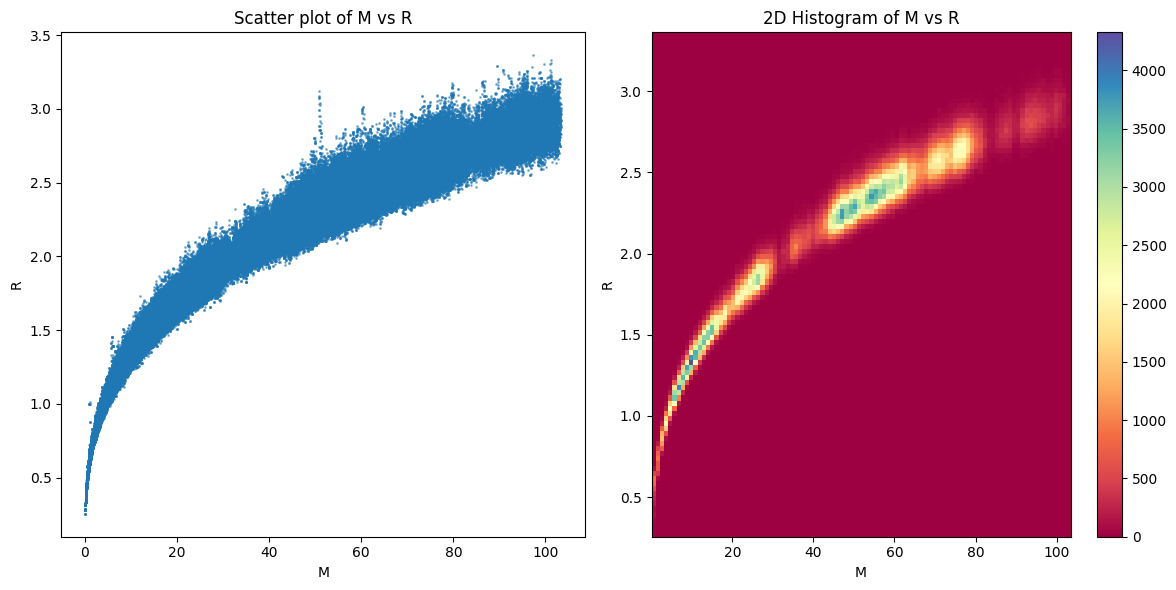

In [20]:
#+COPILOT+Mods
# Scatter plot and 2D histogram
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Scatter plot
axs[0].scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=1)
axs[0].set_xlabel('M')
axs[0].set_ylabel('R')
axs[0].set_title('Scatter plot of M vs R')

# 2D histogram
h = axs[1].hist2d(samples[:, 0], samples[:, 1], bins=100, cmap='Spectral')
axs[1].set_xlabel('M')
axs[1].set_ylabel('R')
axs[1].set_title('2D Histogram of M vs R')

# Add color bar
fig.colorbar(h[3], ax=axs[1])

fig.tight_layout()
#plt.show()

The non-uniform structure here is due to the fact that the MCMC algorithm is exploratory. Not all the parameter space is explored with the number of samples generated.  You may also notice how far the exploration went in this run (masses as large as $M=100$).

#### Implementation MCRA

Let's implemente the MCRA

In [22]:
#+COPILOT+Mods
# Monte Carlo parameters
num_samples = int(1e5)

M_max = 2
R_max = (M_max/k)**(1/3)

M_range = [0, M_max]
R_range = [0, R_max]
samples = []

# Monte Carlo sampling
i = 0
while True:
    M = np.random.uniform(M_range[0], M_range[1])
    R = np.random.uniform(R_range[0], R_range[1])
    
    rho = calculate_rho(M, R)
    
    acceptance_prob = p_rho(rho)

    if acceptance_prob > np.random.rand()*1/(np.sqrt(2*np.pi)*rho_std):
        samples.append((M, R))
        i += 1 
        if i > num_samples:
            break


samples = np.array(samples)
rhos = calculate_rho(samples[:,0],samples[:,1])

As you may notice the MCRA is considerably slower than the MCMC. 

And plot:

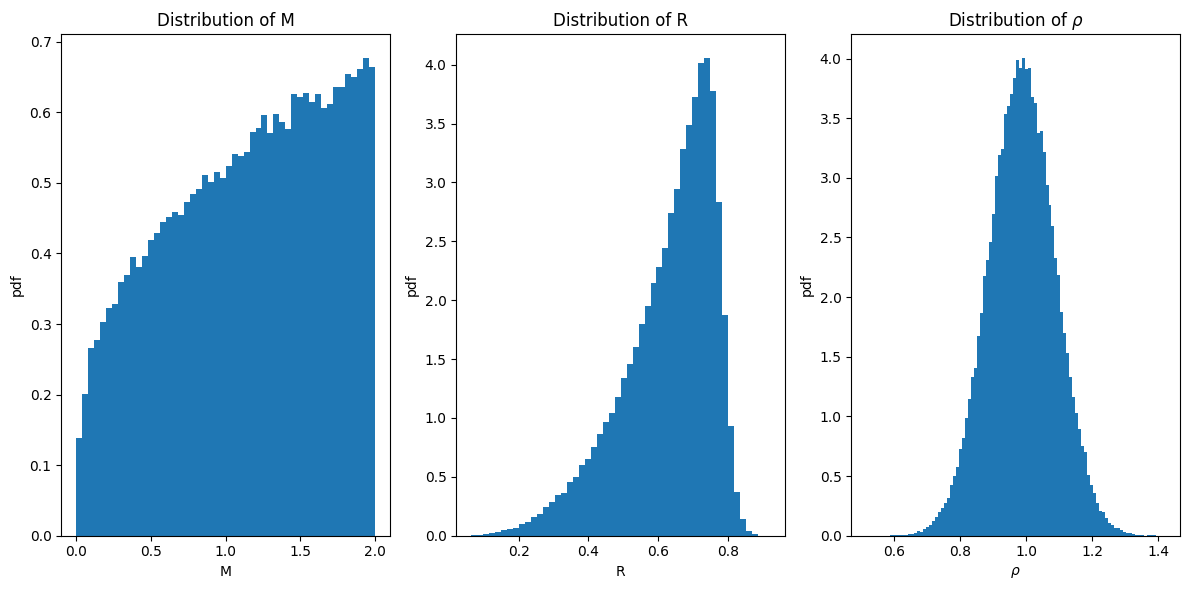

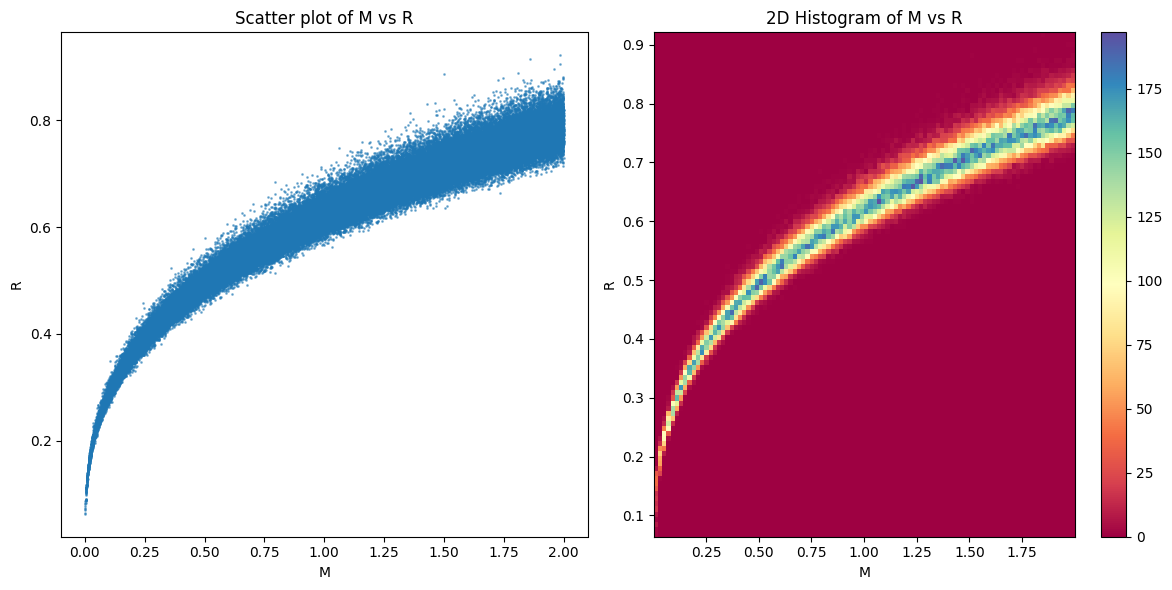

In [23]:
#+COPILOT + Modifications
# Plotting the results
fig, axs = plt.subplots(1,3,figsize=(12, 6))
ax = axs[0]
ax.hist(samples[:, 0], bins=50, density=True)
ax.set_xlabel('M')
ax.set_ylabel('pdf')
ax.set_title('Distribution of M')

ax = axs[1]
ax.hist(samples[:, 1], bins=50, density=True)
ax.set_xlabel('R')
ax.set_ylabel('pdf')
ax.set_title('Distribution of R')

ax = axs[2]
ax.hist(rhos,bins=100,density=True)
ax.set_xlabel(r'$\rho$')
ax.set_ylabel('pdf')
ax.set_title(r'Distribution of $\rho$')

fig.tight_layout()

# Scatter plot and 2D histogram
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Scatter plot
axs[0].scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=1)
axs[0].set_xlabel('M')
axs[0].set_ylabel('R')
axs[0].set_title('Scatter plot of M vs R')

# 2D histogram
h = axs[1].hist2d(samples[:, 0], samples[:, 1], bins=100, cmap='Spectral')
axs[1].set_xlabel('M')
axs[1].set_ylabel('R')
axs[1].set_title('2D Histogram of M vs R')

# Add color bar
fig.colorbar(h[3], ax=axs[1])

fig.tight_layout()
#plt.show()

#### Implementation MCMC periodic boundaries

Let's use now the case of an MCMC with a bounded region with periodic boundaries, i.e. let's assume that $M\in[0,2]$ and $R\in[0,(2/k)^{1/3)}]$:

In [181]:
#+COPILOT+Mods
# MCMC parameters
num_samples = int(1e6)
M_init, R_init = 1.0, 1.0
samples = []

M_max = 2
R_max = (M_max/k)**(1/3)

# MCMC sampling
M, R = M_init, R_init
for _ in range(num_samples):
    # Random walk
    M_new = np.mod(M + np.random.normal(0, 0.1), M_max)
    R_new = np.mod(R + np.random.normal(0, 0.1), R_max)
    
    rho = calculate_rho(M, R)
    rho_new = calculate_rho(M_new, R_new)
    
    acceptance_ratio = p_rho(rho_new) / p_rho(rho)
    
    if acceptance_ratio > np.random.rand():
        M, R = M_new, R_new
    
    samples.append((M, R))

samples = np.array(samples)
rhos = calculate_rho(samples[:,0],samples[:,1])

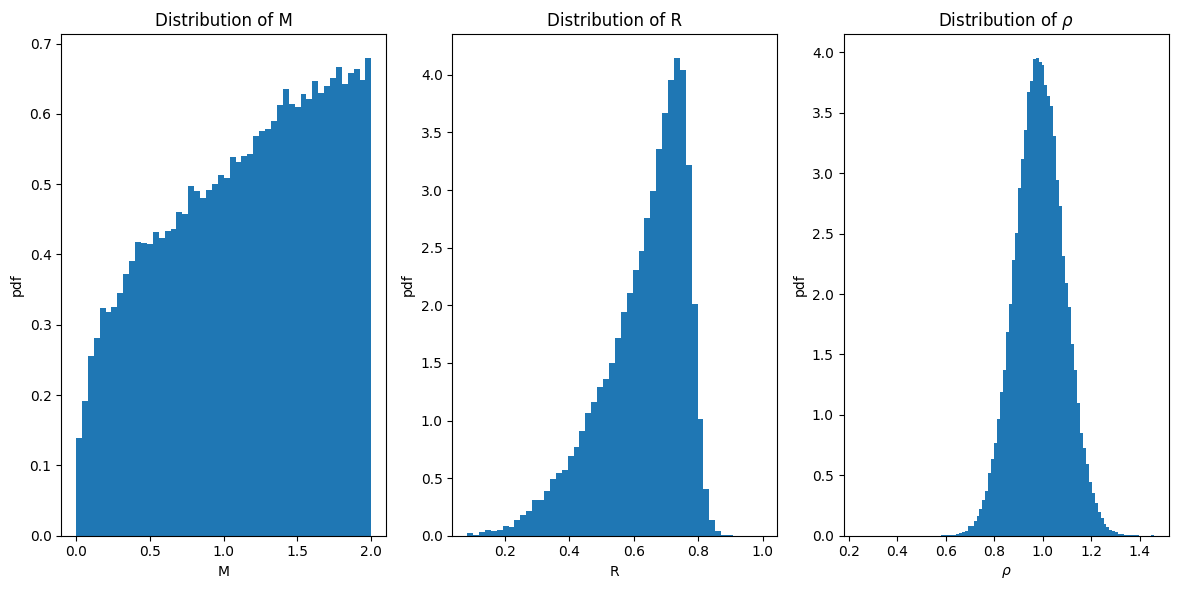

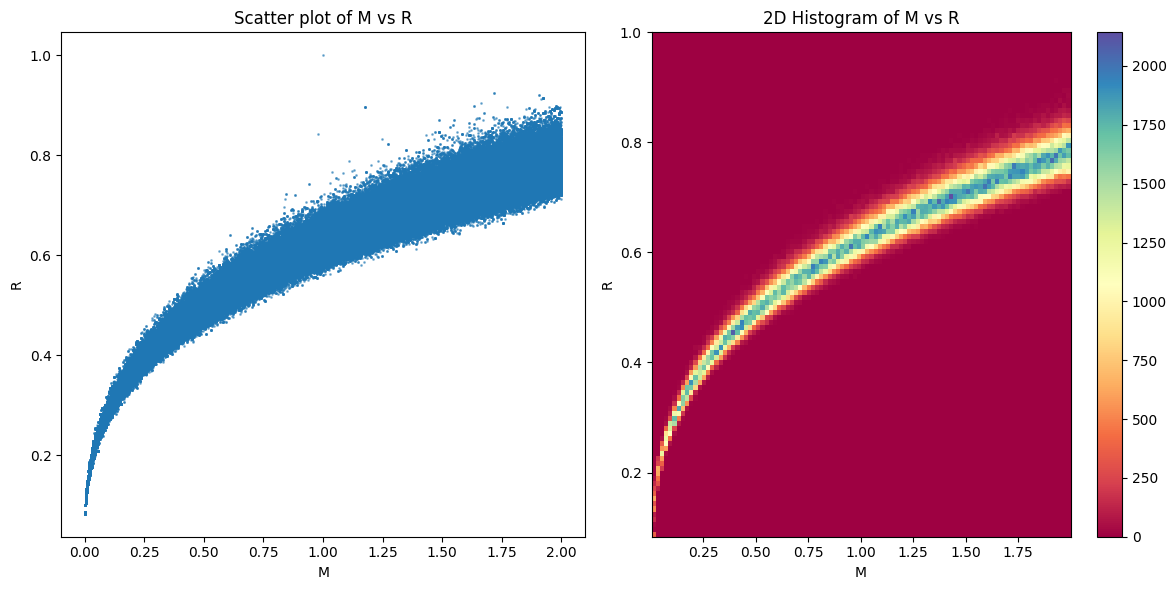

In [182]:
#+COPILOT+Mods
# Plotting the results
fig, axs = plt.subplots(1,3,figsize=(12, 6))
ax = axs[0]
ax.hist(samples[:, 0], bins=50, density=True)
ax.set_xlabel('M')
ax.set_ylabel('pdf')
ax.set_title('Distribution of M')

ax = axs[1]
ax.hist(samples[:, 1], bins=50, density=True)
ax.set_xlabel('R')
ax.set_ylabel('pdf')
ax.set_title('Distribution of R')

ax = axs[2]
ax.hist(rhos,bins=100,density=True)
ax.set_xlabel(r'$\rho$')
ax.set_ylabel('pdf')
ax.set_title(r'Distribution of $\rho$')

fig.tight_layout()

# Scatter plot and 2D histogram
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Scatter plot
axs[0].scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=1)
axs[0].set_xlabel('M')
axs[0].set_ylabel('R')
axs[0].set_title('Scatter plot of M vs R')

# 2D histogram
h = axs[1].hist2d(samples[:, 0], samples[:, 1], bins=100, cmap='Spectral')
axs[1].set_xlabel('M')
axs[1].set_ylabel('R')
axs[1].set_title('2D Histogram of M vs R')

# Add color bar
fig.colorbar(h[3], ax=axs[1])

fig.tight_layout()
#plt.show()

This is much better and well-behaved. No concentrations are detected and no artifacts due to frontiers are detected.

### Rigorous approach

The idea that $q(\mathbf{x})\propto p(f(\mathbf{x}))$, which is the base of the intuitive approach, is not rigorously true. Let's argue why. 

For that purpose let's work on the simplified case of only two variables, $x,y$ and $r = f(x,y)$. The only equality that can be established is:

$$
p(r)dr = \iint_{r \leq f(x, y) \leq r+d r}^{(x, y)} \underset{ }{ } q(x, y) d x d y
$$

The question is how to calculate the area element $d x d y$. 

If we define the *level set* as $L_r=\{(x, y) \mid f(x, y)=r\}$, i.e. the 1-d manifold where the values for which the $x, y$ produce the same value of $r$, then the area around $L_r$ or the shell area can be estimated by:

$$
\int_{L_r}(\text { thickness in normal direction }) \times\left(\text { line element along } L_r\right) \approx \int_{L_r} \frac{d r}{\|\nabla f(x, y)\|} d s
$$
here, we have assumed that $dr=|\nabla f(x, y)|dw$ and $dw$ is a displacement in the direccion perpendicular to the level-set, and $d s$ is a line-element along the level set.

A rigorous probe of this result can be obtained from the Coarea formula ([Wikipedia](https://en.wikipedia.org/wiki/Coarea_formula); [Negro, 2021](https://arxiv.org/pdf/2110.01441)).

Returning to our initial equality and replacing the area element  $d x d y$ with the co area expression we get:

$$
p(r) d r=\int_{L_r} q(x, y) \frac{d r}{\|\nabla f(x, y)\|} d s
$$

Finally assuming that $q(x,y)$ is the same along the level set $L_r$, we obtain:

$$
p(r)=q(x, y) \int_{L_r} \frac{d r}{\|\nabla f(x, y)\|} d s
$$
and hence,

$$
q(x, y)=\frac{p(f(x, y))}{C(f(x,y))}
$$
where 

$$
C(f(x,y)) = \int_{L_{f(x, y)}} \frac{1}{\left\|\nabla f\left(x^{\prime}, y^{\prime}\right)\right\|} d s^{\prime}
$$
is called the coarea factor.

As you may see the simple asumption $q(x,y)\propto p(f(x,y))$ is too simplistic, but still may provide a first approach to the problem.

#### First illustrative example: stellar density

To illustrate our result to the case of the stellar density let's calculate the coarea factor.

For this purpose we need to calculate first the norm of the gradient: 

$$
|\nabla f(M, R)|^2=\left(\frac{k}{R^3}\right)^2+\left(-\frac{3 k M}{R^4}\right)^2
$$

Replaceing and simplifying:

$$
|\nabla f(M, R)| =\frac{k}{R^3} \sqrt{1+9\frac{M^2}{R^2}} = \frac{k}{R^3} \sqrt{1+9 \frac{\rho^2 R^4}{k^2}}
$$

The level set $L_\rho$ in this case is the curve such that:

$$
M(R)=\frac{\rho R^3}{k}, \quad R(R)=R
$$

The line element is in this case:

$$
d s=d R\sqrt{\left(\frac{d M}{d R}\right)^2+\left(\frac{d R}{d R}\right)^2}  = d R\sqrt{1+\frac{9 \rho^2 R^4}{k^2}} 
$$

Doing the algebra:

$$
\frac{1}{|\nabla f|} d s = \frac{R^3}{k} d R
$$
and hence the coarea factor is:

$$
M(\rho)=\int_{R \in D_\rho} \frac{R^3}{k} d R
$$
where $D_\rho$ is the set of values of $R$ that lies in the level set $L_\rho$.  For a given value of $\rho$ the level set is given by the equation $R=(k M/\rho)^3$

In the most simple case in which the mass is bounded in the interval [0,$M_\mathrm{max}$] and hence the radius is also bounded [0,$R_\mathrm{max}(\rho)=(kM_\mathrm{max}/\rho)^{1/3}$] the coarea factor is:

$$
C(\rho) = \frac{R_\mathrm{max}(\rho)^4}{4k} = \frac{k^{1/3}M_\mathrm{max}^{4/3}}{4\rho^{4/3}}
$$

Finally the distribution of $M, R$ is:

$$
q(M,R) = p(\rho(M,R))\frac{4\rho(M,R)^{4/3}}{k^{1/3}M_\mathrm{max}^{4/3}}
$$

For the purpose of implementing the MCMC algorithm we can write the distribution without the constant factors:

$$
q(M,R) \propto p(\rho(M,R)) \rho(M,R)^{4/3}
$$
and as you can see the correcting factor is non-trivial.

##### Implementation

Let's implement it:

In [183]:
# MCMC parameters
num_samples = int(1e6)
M_init, R_init = 1.0, 1.0
samples = []

M_max = 2
R_max = (M_max/k)**(1/3)

# MCMC sampling
M, R = M_init, R_init
for _ in range(num_samples):
    # Random walk
    M_new = np.mod(M + np.random.normal(0, 0.1), M_max)
    R_new = np.mod(R + np.random.normal(0, 0.1), R_max)
    
    rho = calculate_rho(M, R)
    rho_new = calculate_rho(M_new, R_new)

    acceptance_ratio = min(1,(p_rho(rho_new)*rho_new**(4/3))/(p_rho(rho)*rho**(4/3)))
    
    if acceptance_ratio > np.random.rand():
        M, R = M_new, R_new
    
    samples.append((M, R))

samples = np.array(samples)
rhos = calculate_rho(samples[:,0],samples[:,1])

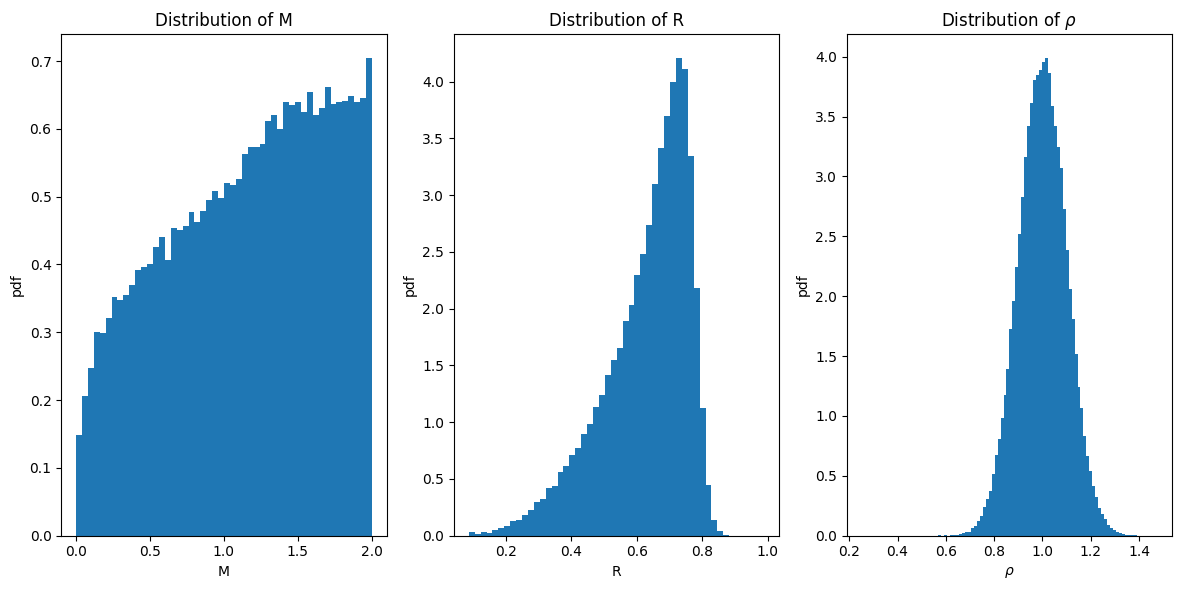

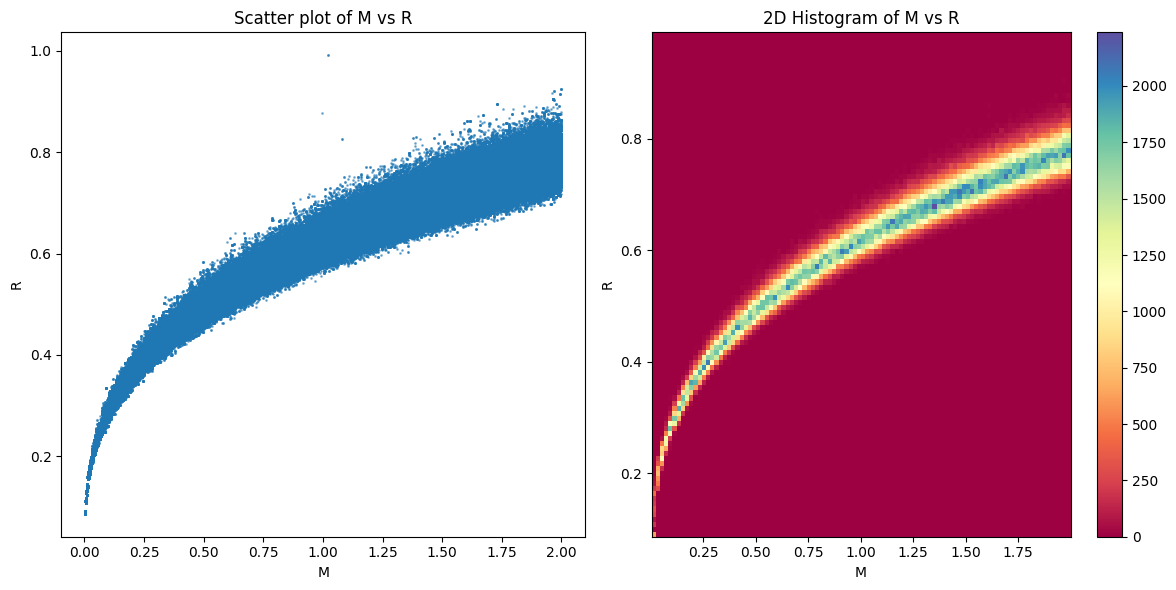

In [184]:
#+COPILOT+Mods
# Plotting the results
fig, axs = plt.subplots(1,3,figsize=(12, 6))
ax = axs[0]
ax.hist(samples[:, 0], bins=50, density=True)
ax.set_xlabel('M')
ax.set_ylabel('pdf')
ax.set_title('Distribution of M')

ax = axs[1]
ax.hist(samples[:, 1], bins=50, density=True)
ax.set_xlabel('R')
ax.set_ylabel('pdf')
ax.set_title('Distribution of R')

ax = axs[2]
ax.hist(rhos,bins=100,density=True)
ax.set_xlabel(r'$\rho$')
ax.set_ylabel('pdf')
ax.set_title(r'Distribution of $\rho$')

fig.tight_layout()

# Scatter plot and 2D histogram
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Scatter plot
axs[0].scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=1)
axs[0].set_xlabel('M')
axs[0].set_ylabel('R')
axs[0].set_title('Scatter plot of M vs R')

# 2D histogram
h = axs[1].hist2d(samples[:, 0], samples[:, 1], bins=100, cmap='Spectral')
axs[1].set_xlabel('M')
axs[1].set_ylabel('R')
axs[1].set_title('2D Histogram of M vs R')

# Add color bar
fig.colorbar(h[3], ax=axs[1])

fig.tight_layout()
#plt.show()

The difference is not evident, but since the acceptance probability are not the same the resulting distribution should also differ. We could compare them:

In [208]:
# MCMC parameters
num_samples = int(1e6)
M_init, R_init = 1.0, 1.0
samples = []
samples_corrected = []

M_max = 2
R_max = (M_max/k)**(1/3)

# MCMC sampling
M, R = M_init, R_init
M_corr, R_corr = M_init, R_init
for _ in range(num_samples):
    # Random walk
    M_new = np.mod(M + np.random.normal(0, 0.1), M_max)
    R_new = np.mod(R + np.random.normal(0, 0.1), R_max)
    
    rho = calculate_rho(M, R)
    rho_corr = calculate_rho(M_corr, R_corr)
    rho_new = calculate_rho(M_new, R_new)

    acceptance_ratio = min(1,(p_rho(rho_new))/(p_rho(rho)))
    
    if acceptance_ratio > np.random.rand():
        M, R = M_new, R_new

    samples.append((M, R))

    acceptance_ratio_corrected = min(1,(p_rho(rho_new)*rho_new**(4/3))/(p_rho(rho_corr)*rho_corr**(4/3)))
    
    if acceptance_ratio_corrected > np.random.rand():
        M_corr, R_corr = M_new, R_new

    samples_corrected.append((M_corr, R_corr))
    
samples = np.array(samples)
samples_corrected = np.array(samples_corrected)

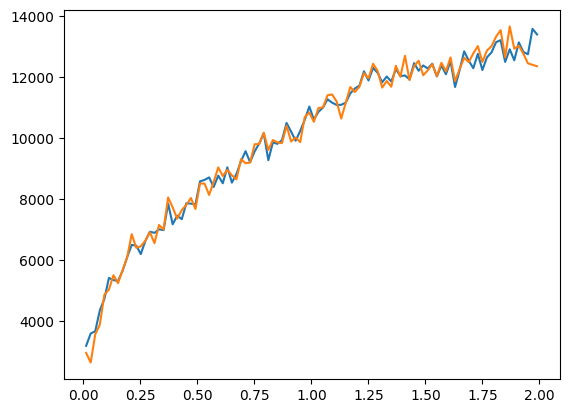

In [209]:
hs,Ms=np.histogram(samples[:,0], bins=100)
Mmeds = (Ms[:-1]+Ms[1:])/2
plt.plot(Mmeds,hs)

hs,Ms=np.histogram(samples_corrected[:,0], bins=100)
Mmeds = (Ms[:-1]+Ms[1:])/2
plt.plot(Mmeds,hs)

The differences are very small due to the similar values of ``rho`` and ``rho_new`` between adjacent values in the MCMC. Our conclusion is that in the MCMC, if the cofactor is a function of the variable $r$ and the steps are small, the effect that this changes have in the calculation of the acceptance probability is also very small. In conclusion we don't need to take them into account.  

### An inversion problem

Now let's suppose that we have the distribution of $M$ and $R$ and get from it the posterior distribution of $\rho$. Then, using the methods in this part we want to calculate the original distribution.

In [36]:
#+COPILOT
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the normal distribution of rho
rho_mean = 1.0
rho_std = 0.1
k=3/(4*np.pi)

# Function to calculate rho given M and R
def calculate_rho(M, R):
    return k * M / R**3

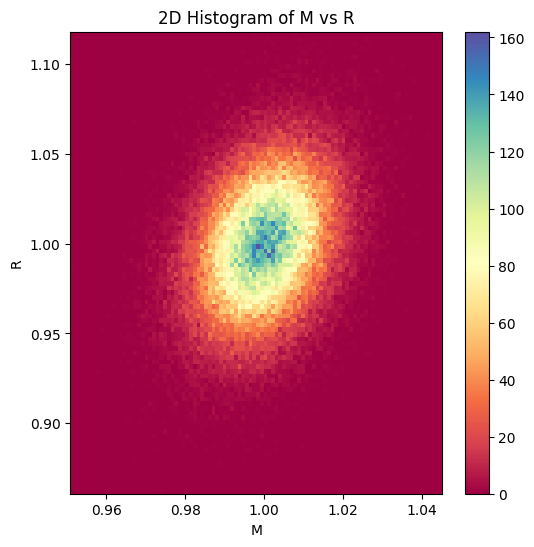

In [37]:
# Parameters
N = int(1e5)
M_mean = 1
R_mean = 1
M_std = 0.01
R_std = 0.03
rho_MR = 0.3

# Mean vector
mean = [M_mean, R_mean]

# Covariance matrix
cov = [[M_std**2, rho_MR * M_std * R_std],
    [rho_MR * M_std * R_std, R_std**2]]

# Generate samples
samples = np.random.multivariate_normal(mean, cov, N)

# Apply truncation
samples = samples[(samples[:, 0] > 0) & (samples[:, 1] > 0)]

# If the number of samples is less than N, generate more samples until we have N valid samples
while len(samples) < N:
    additional_samples = np.random.multivariate_normal(mean, cov, N - len(samples))
    additional_samples = additional_samples[(additional_samples[:, 0] > 0) & (additional_samples[:, 1] > 0)]
    samples = np.vstack([samples, additional_samples])

# Truncate to exactly N samples
samples = samples[:N]

# Extract M and R values
M_values = samples[:, 0]
R_values = samples[:, 1]
rho_values = calculate_rho(M_values, R_values)

# 2D histogram of M and R
fig = plt.figure(figsize=(6, 6))
h = plt.hist2d(M_values, R_values, bins=100, cmap='Spectral')
plt.xlabel('M')
plt.ylabel('R')
plt.title('2D Histogram of M vs R')
plt.colorbar(h[3])
plt.show()

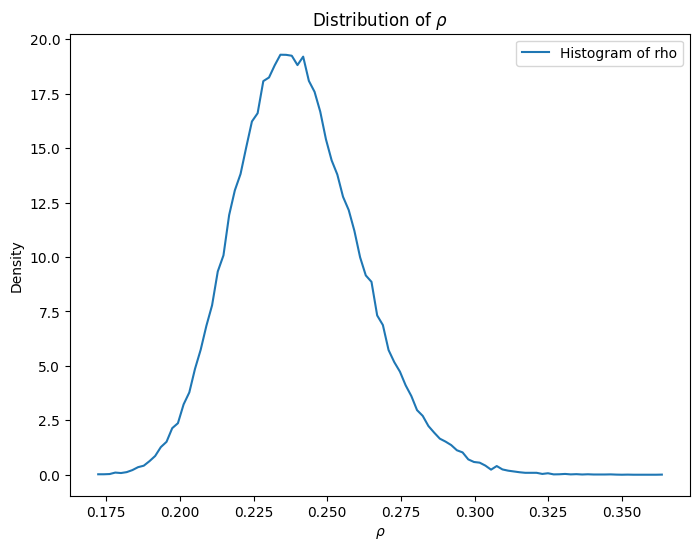

In [38]:
from scipy.interpolate import interp1d

# Calculate rho values from M and R
rho_values = calculate_rho(M_values, R_values)

# Generate histogram of rho values
hist, bin_edges = np.histogram(rho_values, bins=100, density=True)

# Calculate bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create interpolated function
p_rho = interp1d(bin_centers, hist, kind='linear', fill_value=(0,0), bounds_error=False)

# Plot the distribution
plt.figure(figsize=(8, 6))
plt.plot(bin_centers, hist, label='Histogram of rho')
plt.xlabel(r'$\rho$')
plt.ylabel('Density')
plt.title(r'Distribution of $\rho$')
plt.legend()
plt.show()

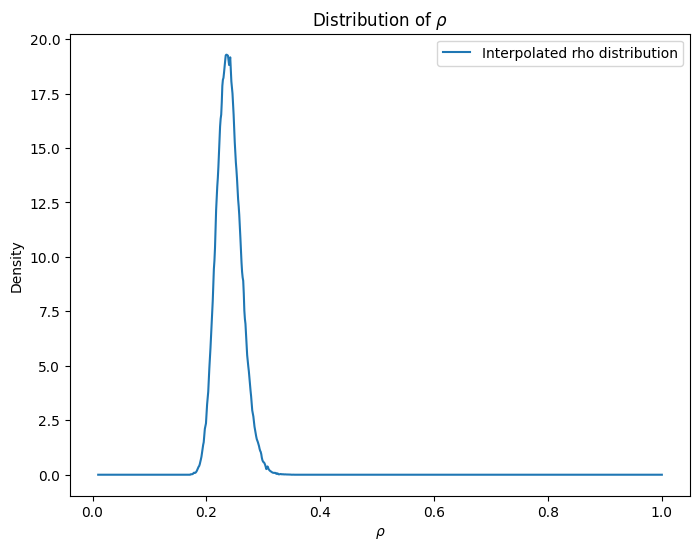

In [39]:
# Define the interval
x_values = np.linspace(0.01, 1, 1000)

# Evaluate the distribution
y_values = p_rho(x_values)

# Plot the distribution
plt.figure(figsize=(8, 6))
plt.plot(x_values, y_values, label='Interpolated rho distribution')
plt.xlabel(r'$\rho$')
plt.ylabel('Density')
plt.title(r'Distribution of $\rho$')
plt.legend()
plt.show()

In [40]:
#+COPILOT+Mods
# MCMC parameters
num_samples = int(1e6)
M_init, R_init = 1.0, 1.0
samples = []

M_max = 1.3
R_max = 1.3

# MCMC sampling
M, R = M_init, R_init
for _ in range(num_samples):
    # Random walk
    M_new = np.mod(M + np.random.normal(0, 0.1), M_max)
    R_new = np.mod(R + np.random.normal(0, 0.1), R_max)
    
    rho = calculate_rho(M, R)
    rho_new = calculate_rho(M_new, R_new)
    
    acceptance_ratio = p_rho(rho_new) / p_rho(rho)
    
    if acceptance_ratio > np.random.rand():
        M, R = M_new, R_new
    
    samples.append((M, R))

samples = np.array(samples)
rhos = calculate_rho(samples[:,0],samples[:,1])

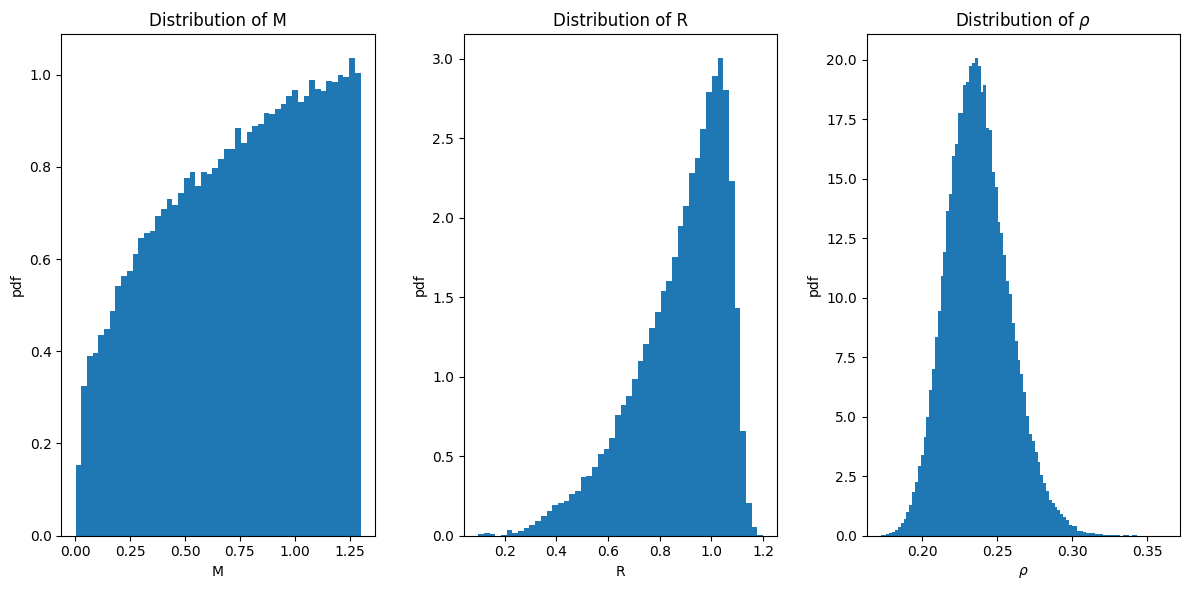

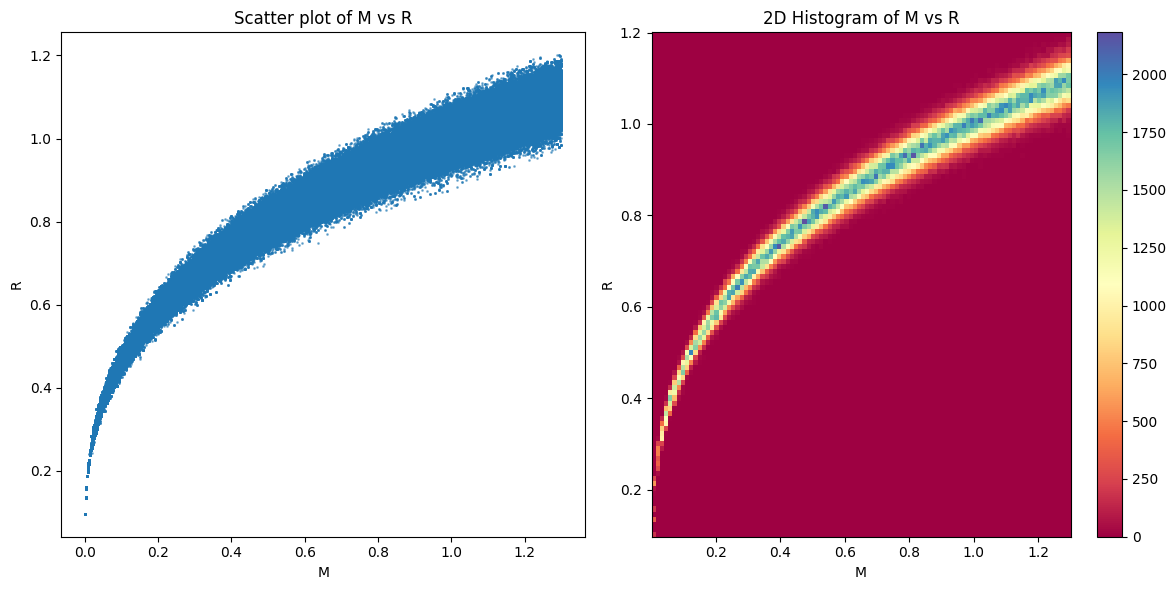

In [41]:
#+COPILOT+Mods
# Plotting the results
fig, axs = plt.subplots(1,3,figsize=(12, 6))
ax = axs[0]
ax.hist(samples[:, 0], bins=50, density=True)
ax.set_xlabel('M')
ax.set_ylabel('pdf')
ax.set_title('Distribution of M')

ax = axs[1]
ax.hist(samples[:, 1], bins=50, density=True)
ax.set_xlabel('R')
ax.set_ylabel('pdf')
ax.set_title('Distribution of R')

ax = axs[2]
ax.hist(rhos,bins=100,density=True)
ax.set_xlabel(r'$\rho$')
ax.set_ylabel('pdf')
ax.set_title(r'Distribution of $\rho$')

fig.tight_layout()

# Scatter plot and 2D histogram
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Scatter plot
axs[0].scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=1)
axs[0].set_xlabel('M')
axs[0].set_ylabel('R')
axs[0].set_title('Scatter plot of M vs R')

# 2D histogram
h = axs[1].hist2d(samples[:, 0], samples[:, 1], bins=100, cmap='Spectral')
axs[1].set_xlabel('M')
axs[1].set_ylabel('R')
axs[1].set_title('2D Histogram of M vs R')

# Add color bar
fig.colorbar(h[3], ax=axs[1])

fig.tight_layout()
#plt.show()

The conclusion is that it is not possible to reconstruct the original distribution of $M,R$ using only the posterior distribution of $\rho$. What this procedure allows us is to find the compatible values of $M$ and $R$ with the posterior distribution.

#### Second illustrative example: radius

In [203]:
# Parameters for the normal distribution of rho
r_mean = 1.0
r_std = 0.1

# Function to calculate rho given M and R
def calculate_r(x, y):
    return (x**2 + y**2)**0.5

# Probability density function for rho
def p_r(r):
    return (1/(r_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((r - r_mean) / r_std)**2)

Text(0.5, 1.0, '2D Histogram of x vs y')

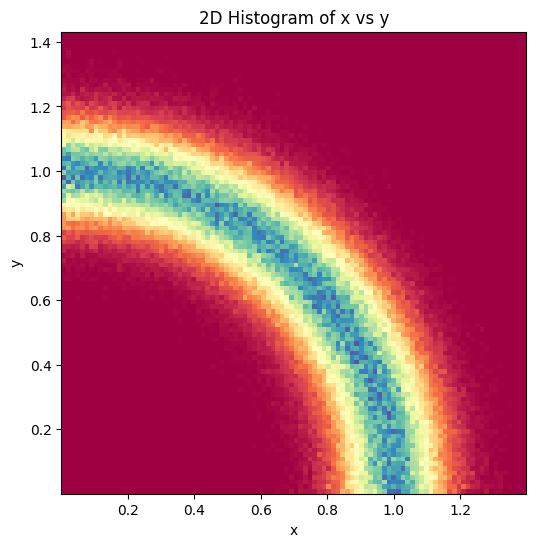

In [204]:
# MCMC parameters
num_samples = int(1e6)
x_init, y_init = 1.0, 1.0
samples = []

x_min = -2
y_min = -2
x_max = 2
y_max = 2

# MCMC sampling
x, y = x_init, y_init
for _ in range(num_samples):
    # Random walk
    x_new = np.mod(x + np.random.normal(0, 0.1), x_max)
    y_new = np.mod(y + np.random.normal(0, 0.1), y_max)
    
    r = calculate_r(x, y)
    r_new = calculate_r(x_new, y_new)

    acceptance_ratio = (p_r(r_new))/(p_r(r))
    
    if acceptance_ratio > np.random.rand():
        x, y = x_new, y_new
    
    samples.append((x, y))

samples = np.array(samples)
rs = calculate_rho(samples[:,0],samples[:,1])

# 2D histogram
fig = plt.figure(figsize=(6, 6))
h = plt.hist2d(samples[:, 0], samples[:, 1], bins=100, cmap='Spectral')
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D Histogram of x vs y')

Corrected:

Text(0.5, 1.0, '2D Histogram of x vs y')

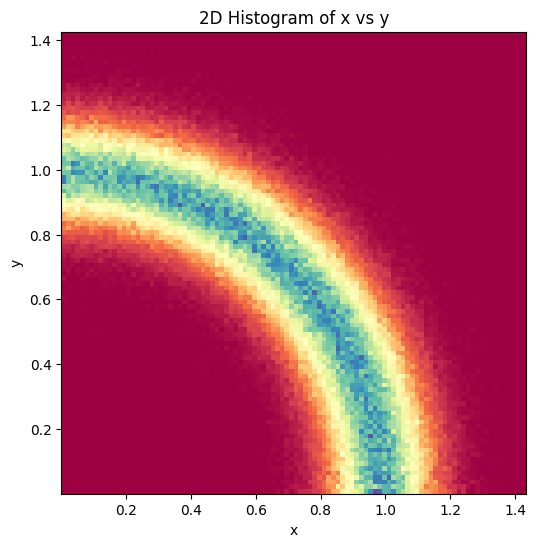

In [206]:
# MCMC parameters
num_samples = int(1e6)
x_init, y_init = 1.0, 1.0
samples = []

x_min = -2
y_min = -2
x_max = 2
y_max = 2

# MCMC sampling
x, y = x_init, y_init
for _ in range(num_samples):
    # Random walk
    x_new = np.mod(x + np.random.normal(0, 0.1), x_max)
    y_new = np.mod(y + np.random.normal(0, 0.1), y_max)
    
    r = calculate_r(x, y)
    r_new = calculate_r(x_new, y_new)

    acceptance_ratio = (p_r(r_new)*r)/(p_r(r)*r_new)
    
    if acceptance_ratio > np.random.rand():
        x, y = x_new, y_new
    
    samples.append((x, y))

samples = np.array(samples)
rs = calculate_rho(samples[:,0],samples[:,1])

# 2D histogram
fig = plt.figure(figsize=(6, 6))
h = plt.hist2d(samples[:, 0], samples[:, 1], bins=100, cmap='Spectral')
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D Histogram of x vs y')

## Source

- This theoretical development were obtained with the assistance of ChatGPT, https://chatgpt.com/share/677ea044-a544-8005-ae32-159ea84e2424. There you can find a generalization to N-dimensions.